# Statistical Inference in Practice

## Loading the Data 

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import sys

# Add project root to path
sys.path.insert(0, str(Path().resolve().parent))

from config import DATA_PROCESSED, FIGURES, RANDOM_SEED

# ── Setup ────────────────────────────────────────────────────────────────
sns.set_theme(style="whitegrid", palette="muted")
rng = np.random.default_rng(RANDOM_SEED)

# ── Load dataset ─────────────────────────────────────────────────────────
# housing_ols_ready.csv: log1p numerics, ordinal-encoded quality columns,
# engineered features, salePrice already log-transformed, nominals as strings
df_stand = pd.read_csv(DATA_PROCESSED / "housing_ols_ready.csv").copy()

# ── Back-transform to USD for inference (this chapter works in USD) ───────
df_stand["salePriceUSD"] = np.expm1(df_stand["salePrice"])
df_stand["grLivAreaSqft"] = np.expm1(df_stand["grLivArea"])  # log1p → sq ft

# ── Consistent aliases ───────────────────────────────────────────────────
price     = df_stand["salePriceUSD"]   # USD scale (for interpretation)
log_price = df_stand["salePrice"]      # log scale (for modeling / normality plots)

# ── Sanity checks ────────────────────────────────────────────────────────
print(f"Loaded housing_ols_ready.csv: {df_stand.shape[0]:,} rows, {df_stand.shape[1]} columns")

print("\nCheck scales:")
print(f"salePrice (log scale) max: {df_stand['salePrice'].max():.2f}")
print(f"salePriceUSD max:          ${df_stand['salePriceUSD'].max():,.0f}")

# ── Summary statistics (USD) ─────────────────────────────────────────────
print("\nKey statistics (original USD scale):")
print(price.describe().apply(lambda x: f"${x:,.0f}").to_frame("salePriceUSD"))

Loaded housing_ols_ready.csv: 2,927 rows, 95 columns

Check scales:
salePrice (log scale) max: 13.53
salePriceUSD max:          $755,000

Key statistics (original USD scale):
      salePriceUSD
count       $2,927
mean      $180,801
std        $79,927
min        $12,789
25%       $129,500
50%       $160,000
75%       $213,500
max       $755,000


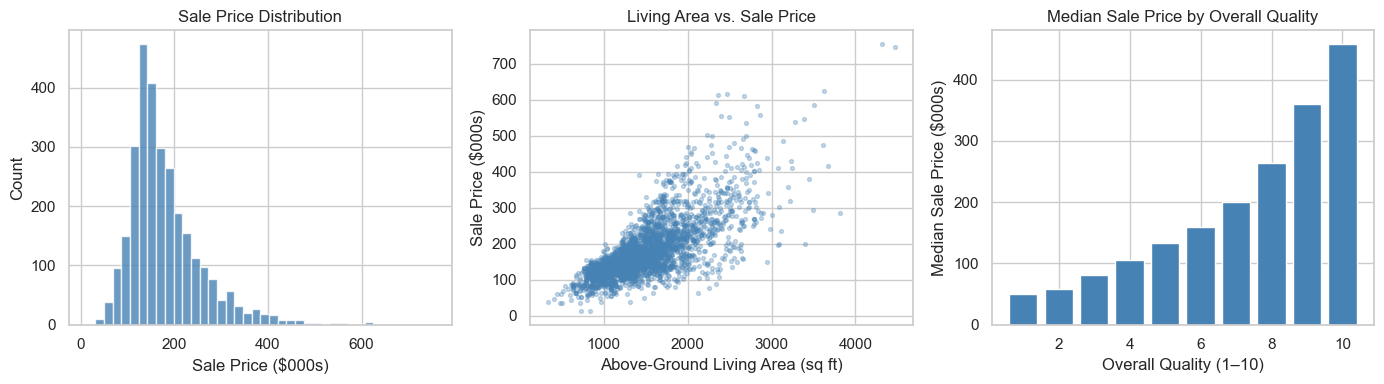

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Panel 1: Sale price distribution
axes[0].hist(price / 1_000, bins=40, color="steelblue",
             edgecolor="white", alpha=0.8)
axes[0].set_title("Sale Price Distribution")
axes[0].set_xlabel("Sale Price ($000s)")
axes[0].set_ylabel("Count")

# Panel 2: Living area vs. sale price
axes[1].scatter(df_stand["grLivAreaSqft"], price / 1_000,
                s=8, alpha=0.3, color="steelblue")
axes[1].set_title("Living Area vs. Sale Price")
axes[1].set_xlabel("Above-Ground Living Area (sq ft)")
axes[1].set_ylabel("Sale Price ($000s)")

# Panel 3: Median sale price by overall quality rating
qual_med = (df_stand.groupby("overallQual")["salePriceUSD"]
              .median()
              .reset_index())
axes[2].bar(qual_med["overallQual"], qual_med["salePriceUSD"] / 1_000,
            color="steelblue", edgecolor="white")
axes[2].set_title("Median Sale Price by Overall Quality")
axes[2].set_xlabel("Overall Quality (1–10)")
axes[2].set_ylabel("Median Sale Price ($000s)")

plt.tight_layout()
plt.savefig(FIGURES / "ch05_ames_eda.png", dpi=150, bbox_inches="tight")
plt.show()

## Estimation and Confidence Intervals

In [6]:
print("── Point Estimates: Sale Price ────────────────────────")
print(f"  Mean:     ${price.mean():>10,.0f}")
print(f"  Median:   ${price.median():>10,.0f}")
print(f"  Std dev:  ${price.std(ddof=1):>10,.0f}")
print(f"  Min:      ${price.min():>10,.0f}")
print(f"  Max:      ${price.max():>10,.0f}")
print(f"  n:        {len(price):>10,}")

── Point Estimates: Sale Price ────────────────────────
  Mean:     $   180,801
  Median:   $   160,000
  Std dev:  $    79,927
  Min:      $    12,789
  Max:      $   755,000
  n:             2,927


### Confidence Intervals for a Single Mean

In [9]:
import pandas as pd
from scipy import stats

def mean_ci(data: pd.Series, alpha: float = 0.05) -> tuple:
    """Return (mean, lower, upper) for a (1-alpha) CI on the mean."""
    n      = len(data)
    mean   = data.mean()
    se     = stats.sem(data)
    t_crit = stats.t.ppf(1 - alpha / 2, df=n - 1)
    margin = t_crit * se
    return mean, mean - margin, mean + margin

mean_p, lo, hi = mean_ci(price)
print(f"Sale Price — Mean: ${mean_p:,.0f}")
print(f"            95% CI: [${lo:,.0f}, ${hi:,.0f}]")
print(f"            Width:  ${hi - lo:,.0f}")

Sale Price — Mean: $180,801
            95% CI: [$177,904, $183,698]
            Width:  $5,793


### Effect of Sample Size on Interval Width

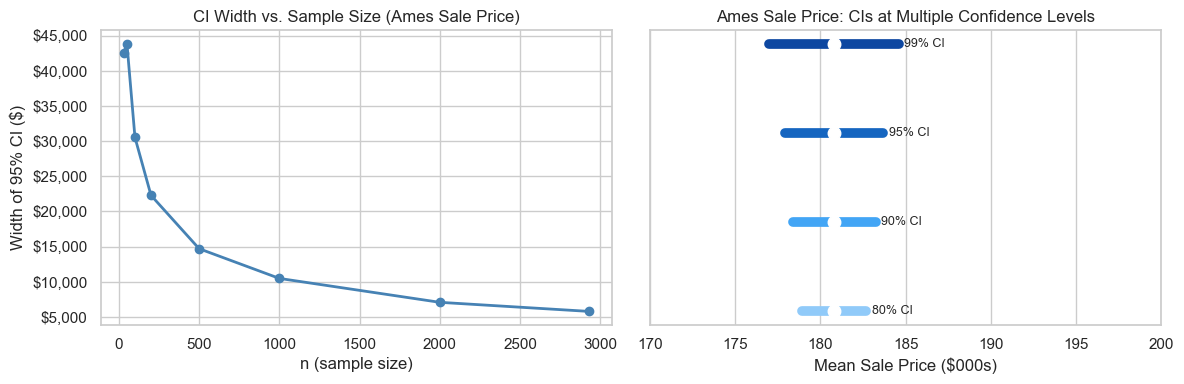

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Panel 1: CI width vs. sample size (sub-sampling from the Ames data)
sample_sizes = [30, 50, 100, 200, 500, 1000, 2000, 2927]
widths = []
for n_sub in sample_sizes:
    sub = price.sample(n=n_sub, random_state=42)
    _, lo_s, hi_s = mean_ci(sub)
    widths.append(hi_s - lo_s)

axes[0].plot(sample_sizes, widths, "o-", color="steelblue", lw=2, ms=6)
axes[0].set_title("CI Width vs. Sample Size (Ames Sale Price)")
axes[0].set_xlabel("n (sample size)")
axes[0].set_ylabel("Width of 95% CI ($)")
axes[0].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f"${x:,.0f}"))

# Panel 2: CIs at multiple confidence levels
levels = [0.80, 0.90, 0.95, 0.99]
colors = ["#90CAF9", "#42A5F5", "#1565C0", "#0D47A1"]
for i, (lev, col) in enumerate(zip(levels, colors)):
    m, lo_l, hi_l = mean_ci(price, alpha=1 - lev)
    axes[1].plot([lo_l/1_000, hi_l/1_000], [i, i],
                 lw=7, color=col, solid_capstyle="round")
    axes[1].plot(m / 1_000, i, "o", color="white", zorder=5, ms=9)
    axes[1].text(hi_l / 1_000 + 0.3, i,
                 f"{int(lev*100)}% CI", va="center", fontsize=9)

axes[1].set_title("Ames Sale Price: CIs at Multiple Confidence Levels")
axes[1].set_xlabel("Mean Sale Price ($000s)")
axes[1].set_yticks([])
axes[1].set_xlim(170, 200)

plt.tight_layout()
plt.savefig(FIGURES / "ch05_ci_width.png", dpi=150, bbox_inches="tight")
plt.show()

### Confidence Intervals for a Proportion

In [11]:
from statsmodels.stats.proportion import proportion_confint

n_total   = len(df_stand)
n_twocar  = (df_stand["garageCars"] >= 2).sum()
prop_twocar = n_twocar / n_total

ci_w = proportion_confint(n_twocar, n_total, alpha=0.05, method="wilson")
print(f"Homes with ≥ 2-car garage: {n_twocar:,} / {n_total:,}")
print(f"Sample proportion:         {prop_twocar:.3f}")
print(f"Wilson 95% CI:             ({ci_w[0]:.3f}, {ci_w[1]:.3f})")

Homes with ≥ 2-car garage: 1,991 / 2,927
Sample proportion:         0.680
Wilson 95% CI:             (0.663, 0.697)


### Confidence Intervals for the Difference Between Two Means

In [12]:
normal   = df_stand[df_stand["saleCondition"] == "Normal"]["salePriceUSD"]
abnormal = df_stand[df_stand["saleCondition"] != "Normal"]["salePriceUSD"]

def welch_ci(g1: pd.Series, g2: pd.Series,
             alpha: float = 0.05) -> tuple:
    """CI for (mean_g1 - mean_g2) using Welch's method."""
    n1, n2   = len(g1), len(g2)
    v1, v2   = g1.var(ddof=1), g2.var(ddof=1)
    se       = np.sqrt(v1 / n1 + v2 / n2)
    num      = (v1/n1 + v2/n2)**2
    denom    = (v1/n1)**2/(n1-1) + (v2/n2)**2/(n2-1)
    df_w     = num / denom
    t_crit   = stats.t.ppf(1 - alpha / 2, df=df_w)
    diff     = g1.mean() - g2.mean()
    return diff, diff - t_crit * se, diff + t_crit * se

diff, lo_d, hi_d = welch_ci(normal, abnormal)
print(f"Normal sales     — Mean: ${normal.mean():,.0f}  (n={len(normal):,})")
print(f"Abnormal sales   — Mean: ${abnormal.mean():,.0f}  (n={len(abnormal):,})")
print(f"Difference:              ${diff:,.0f}")
print(f"95% CI for difference:  [${lo_d:,.0f}, ${hi_d:,.0f}]")

Normal sales     — Mean: $175,568  (n=2,413)
Abnormal sales   — Mean: $205,368  (n=514)
Difference:              $-29,800
95% CI for difference:  [$-39,710, $-19,890]


### One-Sample t-Test

In [15]:
t_stat, p_value = stats.ttest_1samp(price, popmean=175_000)
n = len(price)

print("One-sample t-test: Ames mean price vs. $175,000")
print(f"  Sample mean:  ${price.mean():,.0f}")
print(f"  t = {t_stat:.3f}")
print(f"  p = {p_value:.4f}")
print(f"  n = {n:,}")

One-sample t-test: Ames mean price vs. $175,000
  Sample mean:  $180,801
  t = 3.926
  p = 0.0001
  n = 2,927


### Two-Sample t-Test (Welch's)

In [16]:
ac_yes = df_stand[df_stand["centralAir"] == "Y"]["salePriceUSD"]
ac_no  = df_stand[df_stand["centralAir"] == "N"]["salePriceUSD"]

t_stat, p_val = stats.ttest_ind(ac_yes, ac_no, equal_var=False)

print("Welch two-sample t-test: Central Air (Y vs. N)")
print(f"  With A/C:    ${ac_yes.mean():,.0f}  (n={len(ac_yes):,})")
print(f"  Without A/C: ${ac_no.mean():,.0f}  (n={len(ac_no):,})")
print(f"  t = {t_stat:.3f},  p = {p_val:.2e}")

Welch two-sample t-test: Central Air (Y vs. N)
  With A/C:    $186,464  (n=2,731)
  Without A/C: $101,890  (n=196)
  t = 27.430,  p = 8.34e-88


### Paired t-Test

In [17]:
prices_2007 = df_stand[df_stand["yrSold"] == 2007]["salePriceUSD"]
prices_2008 = df_stand[df_stand["yrSold"] == 2008]["salePriceUSD"]

# Align to equal length for paired test demonstration
n_pair = min(len(prices_2007), len(prices_2008))
p07 = prices_2007.iloc[:n_pair].values
p08 = prices_2008.iloc[:n_pair].values

t_stat, p_val = stats.ttest_rel(p07, p08)
print("Paired t-test: 2007 vs. 2008 sale prices (matched subsample)")
print(f"  Mean 2007: ${p07.mean():,.0f}  (n={n_pair:,})")
print(f"  Mean 2008: ${p08.mean():,.0f}  (n={n_pair:,})")
print(f"  t = {t_stat:.3f},  p = {p_val:.4f}")

Paired t-test: 2007 vs. 2008 sale prices (matched subsample)
  Mean 2007: $186,645  (n=621)
  Mean 2008: $178,872  (n=621)
  t = 1.881,  p = 0.0604


### One-Way ANOVA: Comparing Neighbourhood Price Levels

In [18]:
top5_nbhd = (df_stand["neighborhood"]
             .value_counts()
             .head(5)
             .index
             .tolist())

nbhd_groups = [
    df_stand[df_stand["neighborhood"] == nbhd]["salePriceUSD"].values
    for nbhd in top5_nbhd
]

f_stat, p_val = stats.f_oneway(*nbhd_groups)

print("One-way ANOVA: Sale Price across top-5 neighbourhoods")
print(f"  F = {f_stat:.2f},  p = {p_val:.2e}\n")
for nbhd, grp in zip(top5_nbhd, nbhd_groups):
    print(f"  {nbhd:12s}  n={len(grp):3d}  mean=${grp.mean():,.0f}")

One-way ANOVA: Sale Price across top-5 neighbourhoods
  F = 231.62,  p = 1.26e-150

  NAmes         n=443  mean=$145,097
  CollgCr       n=267  mean=$201,803
  OldTown       n=239  mean=$123,992
  Edwards       n=191  mean=$130,131
  Somerst       n=182  mean=$229,707


#### Post-Hoc Testing: Tukey's HSD

In [19]:
from scipy.stats import tukey_hsd

result = tukey_hsd(*nbhd_groups)

print("Tukey HSD pairwise comparisons")
print(f"{'Pair':32s}  p-adj   sig")
print("-" * 50)
for i in range(len(top5_nbhd)):
    for j in range(i + 1, len(top5_nbhd)):
        p = result.pvalue[i, j]
        sig = "***" if p < 0.001 else ("**" if p < 0.01
                                        else ("*" if p < 0.05 else "ns"))
        print(f"  {top5_nbhd[i]:12s} vs {top5_nbhd[j]:12s}"
              f"  {p:.4f}  {sig}")

Tukey HSD pairwise comparisons
Pair                              p-adj   sig
--------------------------------------------------
  NAmes        vs CollgCr       0.0000  ***
  NAmes        vs OldTown       0.0000  ***
  NAmes        vs Edwards       0.0015  **
  NAmes        vs Somerst       0.0000  ***
  CollgCr      vs OldTown       0.0000  ***
  CollgCr      vs Edwards       0.0000  ***
  CollgCr      vs Somerst       0.0000  ***
  OldTown      vs Edwards       0.6353  ns
  OldTown      vs Somerst       0.0000  ***
  Edwards      vs Somerst       0.0000  ***


### Chi-Square Test: Categorical Association

In [20]:
df_stand["saleCondBinary"] = df_stand["saleCondition"].apply(
    lambda x: "Normal" if x == "Normal" else "Abnormal"
)
ct = pd.crosstab(df_stand["saleCondBinary"], df_stand["centralAir"],
                 rownames=["Sale Condition"], colnames=["Central Air"])
print(ct)

chi2, p_chi, dof, expected = stats.chi2_contingency(ct)
print(f"\nChi-square test of independence")
print(f"  χ² = {chi2:.3f},  df = {dof},  p = {p_chi:.4f}")

Central Air       N     Y
Sale Condition           
Abnormal         43   471
Normal          153  2260

Chi-square test of independence
  χ² = 2.467,  df = 1,  p = 0.1163


### Correlation Test: Living Area and Sale Price

Pearson  r = 0.701,  p = 0.00e+00
Spearman ρ = 0.724,  p = 0.00e+00


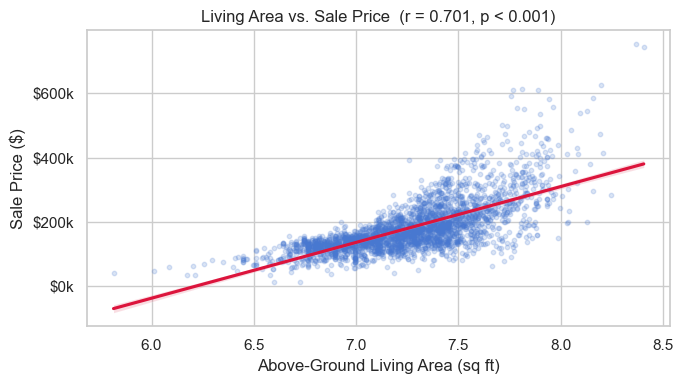

In [21]:
r_p, p_p = stats.pearsonr(df_stand["grLivArea"], price)
r_s, p_s = stats.spearmanr(df_stand["grLivArea"], price)

print(f"Pearson  r = {r_p:.3f},  p = {p_p:.2e}")
print(f"Spearman ρ = {r_s:.3f},  p = {p_s:.2e}")

fig, ax = plt.subplots(figsize=(7, 4))
sns.regplot(data=df_stand, x="grLivArea", y="salePriceUSD",
            ax=ax, scatter_kws={"alpha": 0.2, "s": 10},
            line_kws={"color": "crimson"})
ax.set_title(f"Living Area vs. Sale Price  "
             f"(r = {r_p:.3f}, p < 0.001)")
ax.set_xlabel("Above-Ground Living Area (sq ft)")
ax.set_ylabel("Sale Price ($)")
ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f"${x/1_000:.0f}k"))
plt.tight_layout()
plt.savefig(FIGURES / "ch05_correlation.png", dpi=150, bbox_inches="tight")
plt.show()

## p-values and Practical Significance

### The Significance Threshold α and Error Types

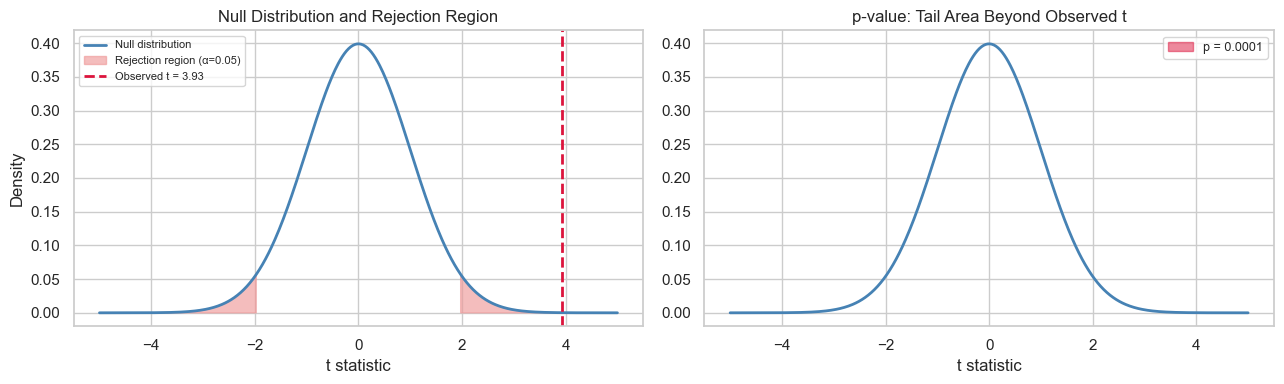

In [22]:
# Visualise the null distribution, rejection region, and observed t
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

t_df = len(price) - 1
x = np.linspace(-5, 5, 500)
y = stats.t.pdf(x, df=t_df)
t_crit_val = stats.t.ppf(0.975, df=t_df)
t_obs_val  = stats.ttest_1samp(price, 175_000).statistic

# Panel 1: rejection region
axes[0].plot(x, y, color="steelblue", lw=2, label="Null distribution")
axes[0].fill_between(x, y, where=(np.abs(x) >= t_crit_val),
                     color="#EF9A9A", alpha=0.65,
                     label=f"Rejection region (α=0.05)")
axes[0].axvline(t_obs_val, color="crimson", lw=2, linestyle="--",
                label=f"Observed t = {t_obs_val:.2f}")
axes[0].set_title("Null Distribution and Rejection Region")
axes[0].set_xlabel("t statistic")
axes[0].set_ylabel("Density")
axes[0].legend(fontsize=8)

# Panel 2: p-value as tail area
axes[1].plot(x, y, color="steelblue", lw=2)
axes[1].fill_between(x, y, where=(np.abs(x) >= abs(t_obs_val)),
                     color="crimson", alpha=0.5,
                     label=f"p = {stats.ttest_1samp(price,175_000).pvalue:.4f}")
axes[1].set_title("p-value: Tail Area Beyond Observed t")
axes[1].set_xlabel("t statistic")
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig(FIGURES / "ch05_pvalue.png", dpi=150, bbox_inches="tight")
plt.show()

### Statistical vs. Practical Significance

#### Cohen's d for Two Means

In [23]:
def cohen_d(g1: pd.Series, g2: pd.Series) -> float:
    n1, n2 = len(g1), len(g2)
    sp = np.sqrt(((n1-1)*g1.var(ddof=1) + (n2-1)*g2.var(ddof=1))
                 / (n1 + n2 - 2))
    return (g1.mean() - g2.mean()) / sp

d_ac  = cohen_d(ac_yes, ac_no)
d_sc  = cohen_d(normal, abnormal)

print(f"Central Air effect — Cohen's d = {d_ac:.3f}  "
      f"({'large' if abs(d_ac)>=0.8 else 'medium' if abs(d_ac)>=0.5 else 'small'})")
print(f"Sale Condition     — Cohen's d = {d_sc:.3f}  "
      f"({'large' if abs(d_sc)>=0.8 else 'medium' if abs(d_sc)>=0.5 else 'small'})")

Central Air effect — Cohen's d = 1.097  (large)
Sale Condition     — Cohen's d = -0.377  (small)


#### Eta-Squared for ANOVA

In [24]:
all_vals   = np.concatenate(nbhd_groups)
grand_mean = all_vals.mean()

ss_between = sum(len(g) * (g.mean() - grand_mean)**2
                 for g in nbhd_groups)
ss_total   = sum((v - grand_mean)**2 for v in all_vals)
eta_sq     = ss_between / ss_total

print(f"η² = {eta_sq:.3f}  "
      f"— neighbourhood explains {eta_sq*100:.1f}% of price variance")

η² = 0.413  — neighbourhood explains 41.3% of price variance


#### Cramér's V for Chi-Square

In [25]:
n_obs     = ct.values.sum()
k         = min(ct.shape) - 1
cramers_v = np.sqrt(chi2 / (n_obs * k))
print(f"Cramér's V = {cramers_v:.3f}")

Cramér's V = 0.029


### Statistical Power and Sample Size Planning

In [26]:
from scipy.stats import norm

def n_required(d: float, alpha: float = 0.05,
               power: float = 0.80) -> int:
    """Sample size per group for a two-sample t-test."""
    z_a = norm.ppf(1 - alpha / 2)
    z_b = norm.ppf(power)
    return int(np.ceil(2 * ((z_a + z_b) / d) ** 2))

print("Required n per group  (α=0.05, power=80%)")
for d_val, label in [(0.2, "small"), (0.5, "medium"), (0.8, "large"),
                     (1.0, "very large")]:
    print(f"  d = {d_val} ({label:10s}): n = {n_required(d_val):4d}")

Required n per group  (α=0.05, power=80%)
  d = 0.2 (small     ): n =  393
  d = 0.5 (medium    ): n =   63
  d = 0.8 (large     ): n =   25
  d = 1.0 (very large): n =   16


## Common Pitfalls in Statistical Inference

### Multiple Comparisons

In [27]:
from statsmodels.stats.multitest import multipletests

# Run all pairwise t-tests among top-5 neighbourhoods
pairs, raw_p = [], []
for i in range(len(top5_nbhd)):
    for j in range(i + 1, len(top5_nbhd)):
        _, p = stats.ttest_ind(nbhd_groups[i], nbhd_groups[j],
                               equal_var=False)
        pairs.append(f"{top5_nbhd[i]} vs {top5_nbhd[j]}")
        raw_p.append(p)

raw_p = np.array(raw_p)
_, p_bonf, _, _ = multipletests(raw_p, method="bonferroni")
_, p_bh,   _, _ = multipletests(raw_p, method="fdr_bh")

print(f"{'Pair':35s}  {'Raw p':>8}  {'Bonf':>8}  {'BH':>8}  sig")
print("-" * 70)
for pair, rp, pb, bh in zip(pairs, raw_p, p_bonf, p_bh):
    sig = "***" if pb < 0.001 else ("*" if pb < 0.05 else "ns")
    print(f"{pair:35s}  {rp:8.4f}  {pb:8.4f}  {bh:8.4f}  {sig}")

Pair                                    Raw p      Bonf        BH  sig
----------------------------------------------------------------------
NAmes vs CollgCr                       0.0000    0.0000    0.0000  ***
NAmes vs OldTown                       0.0000    0.0000    0.0000  ***
NAmes vs Edwards                       0.0001    0.0010    0.0001  *
NAmes vs Somerst                       0.0000    0.0000    0.0000  ***
CollgCr vs OldTown                     0.0000    0.0000    0.0000  ***
CollgCr vs Edwards                     0.0000    0.0000    0.0000  ***
CollgCr vs Somerst                     0.0000    0.0000    0.0000  ***
OldTown vs Edwards                     0.1739    1.0000    0.1739  ns
OldTown vs Somerst                     0.0000    0.0000    0.0000  ***
Edwards vs Somerst                     0.0000    0.0000    0.0000  ***


### Assumption Checking: Normality and Equal Variances

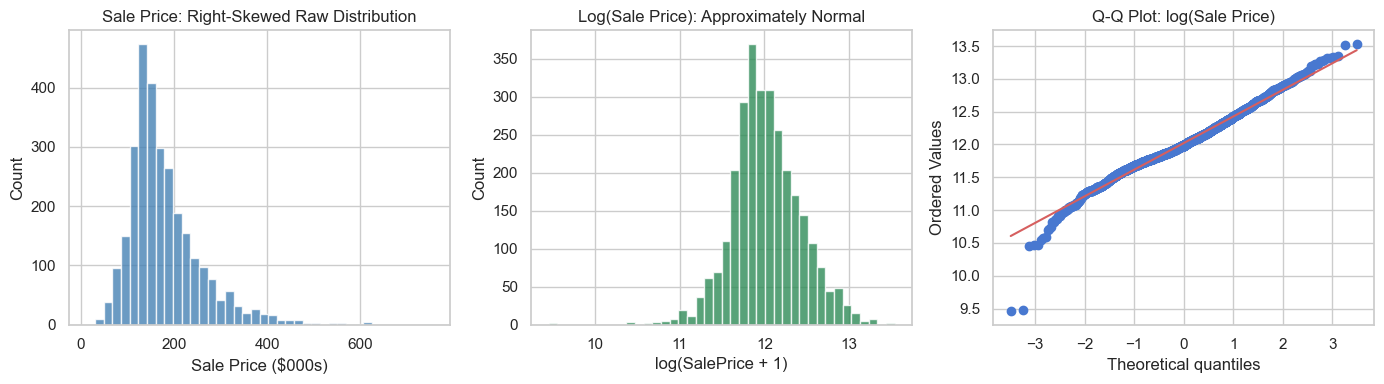

Levene's test (Central Air Y vs. N):  p = 0.0000
→ Variances are unequal — Welch t-test appropriate


In [28]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Panel 1: Histogram of raw sale prices — clearly right-skewed
axes[0].hist(price / 1_000, bins=40, color="steelblue",
             edgecolor="white", alpha=0.8)
axes[0].set_title("Sale Price: Right-Skewed Raw Distribution")
axes[0].set_xlabel("Sale Price ($000s)")
axes[0].set_ylabel("Count")

# Panel 2: Log-transformed prices — approximately normal
axes[1].hist(log_price, bins=40, color="seagreen",
             edgecolor="white", alpha=0.8)
axes[1].set_title("Log(Sale Price): Approximately Normal")
axes[1].set_xlabel("log(SalePrice + 1)")
axes[1].set_ylabel("Count")

# Panel 3: Q-Q plot for log price
stats.probplot(log_price, dist="norm", plot=axes[2])
axes[2].set_title("Q-Q Plot: log(Sale Price)")

plt.tight_layout()
plt.savefig(FIGURES / "ch05_normality.png", dpi=150, bbox_inches="tight")
plt.show()

# Levene's test for equal variances between A/C groups
lev_stat, lev_p = stats.levene(ac_yes, ac_no)
print(f"Levene's test (Central Air Y vs. N):  p = {lev_p:.4f}")
print("→ Variances are " +
      ("unequal — Welch t-test appropriate" if lev_p < 0.05
       else "not significantly different"))

### p-Hacking and Pre-Registration

### Practical Inference Workflow

In [29]:
def inference_report(g1: pd.Series, g2: pd.Series,
                     name1: str = "Group 1",
                     name2: str = "Group 2",
                     alpha: float = 0.05) -> None:
    """Complete two-group inference: assumptions, test, effect size, CI."""
    t_stat, p_val = stats.ttest_ind(g1, g2, equal_var=False)
    d             = cohen_d(g1, g2)
    diff, lo, hi  = welch_ci(g1, g2, alpha=alpha)
    lev_p         = stats.levene(g1, g2).pvalue
    sw_p1         = stats.shapiro(g1.sample(min(len(g1), 50),
                                            random_state=0)).pvalue
    sw_p2         = stats.shapiro(g2.sample(min(len(g2), 50),
                                            random_state=0)).pvalue

    print(f"\n{'─'*58}")
    print(f"  Inference Report: {name1} vs. {name2}")
    print(f"{'─'*58}")
    print(f"  n:              {name1}={len(g1):,}, {name2}={len(g2):,}")
    print(f"  Means:          {name1}=${g1.mean():,.0f}, "
                             f"{name2}=${g2.mean():,.0f}")
    print(f"  Mean diff:      ${diff:,.0f}  "
          f"95% CI: [${lo:,.0f}, ${hi:,.0f}]")
    print(f"  Welch t:        {t_stat:.3f}")
    print(f"  p-value:        {p_val:.2e}  "
          f"({'significant' if p_val < alpha else 'not significant'}"
          f" at α={alpha})")
    print(f"  Cohen's d:      {d:.3f}  "
          f"({'large' if abs(d)>=0.8 else 'medium' if abs(d)>=0.5 else 'small'})")
    print(f"  Levene's p:     {lev_p:.4f}  "
          f"({'unequal variances' if lev_p < 0.05 else 'variances OK'})")
    print(f"  Shapiro p:      {name1}={sw_p1:.4f}, "
          f"{name2}={sw_p2:.4f}")
    print(f"{'─'*58}\n")

inference_report(ac_yes, ac_no, "Central Air Y", "Central Air N")


──────────────────────────────────────────────────────────
  Inference Report: Central Air Y vs. Central Air N
──────────────────────────────────────────────────────────
  n:              Central Air Y=2,731, Central Air N=196
  Means:          Central Air Y=$186,464, Central Air N=$101,890
  Mean diff:      $84,574  95% CI: [$78,509, $90,639]
  Welch t:        27.430
  p-value:        8.34e-88  (significant at α=0.05)
  Cohen's d:      1.097  (large)
  Levene's p:     0.0000  (unequal variances)
  Shapiro p:      Central Air Y=0.0000, Central Air N=0.0416
──────────────────────────────────────────────────────────

